**Experiment 4**

In [1]:
# Cell 1 — Install dependencies
!pip -q install opacus==1.4.0 tqdm pandas matplotlib torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/224.8 kB 9.2 MB/s eta 0:00:00


In [2]:
# Cell 2 — Imports + reproducibility
import os, math, random
from copy import deepcopy
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

import matplotlib.pyplot as plt



# Wider alpha grid => avoids "optimal order is the largest alpha" warning
RDP_ALPHAS = (
    [1.01, 1.05] +
    [1.1 + 0.1*i for i in range(0, 90)] +      # 1.1..10.0
    list(range(11, 64)) + [64, 128, 256, 512]
)

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


In [3]:
# Cell 3 — Dataset: CIFAR-10 + loaders
# (Replaces Fashion-MNIST)

transform = T.Compose([
    T.ToTensor(),
    # Standard CIFAR-10 normalization
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616))
])

train_ds = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_ds  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

test_loader = DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
print("train:", len(train_ds), "test:", len(test_ds))

100%|██████████| 170M/170M [00:12<00:00, 13.8MB/s]


train: 50000 test: 10000


In [4]:
# Cell 4 — PUBLIC set + IID clients (DISJOINT, recommended for paper)
# Public points removed from private client datasets.

NUM_CLASSES = 10
PUBLIC_PER_CLASS = 20      # 200 public points (try 30 => 300)
SAMPLES_PER_CLIENT = 10
CLIENTS_PER_ROUND = 100

def extract_public_per_class(dataset, per_class=20, seed=0):
    rng = np.random.default_rng(seed)
    targets = np.array(dataset.targets)
    public_idx = []
    for k in range(NUM_CLASSES):
        cls_idx = np.where(targets == k)[0]
        rng.shuffle(cls_idx)
        public_idx.extend(cls_idx[:per_class].tolist())
    return sorted(public_idx)

public_idx = extract_public_per_class(train_ds, per_class=PUBLIC_PER_CLASS, seed=0)

all_train_idx = np.arange(len(train_ds))
mask = np.ones(len(train_ds), dtype=bool)
mask[np.array(public_idx)] = False
avail_idx = all_train_idx[mask]  # private-only indices

NUM_CLIENTS = len(avail_idx) // SAMPLES_PER_CLIENT
private_needed = NUM_CLIENTS * SAMPLES_PER_CLIENT
avail_idx = avail_idx[:private_needed]

def build_iid_clients_from_indices(indices, num_clients, samples_per_client, seed=0):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(indices)
    return [perm[i*samples_per_client:(i+1)*samples_per_client].tolist()
            for i in range(num_clients)]

clients = build_iid_clients_from_indices(avail_idx, NUM_CLIENTS, SAMPLES_PER_CLIENT, seed=0)

print("public samples:", len(public_idx), f"(per_class={PUBLIC_PER_CLASS})")
print("private samples:", len(avail_idx))
print("NUM_CLIENTS:", NUM_CLIENTS, "| samples/client:", SAMPLES_PER_CLIENT, "| clients/round:", CLIENTS_PER_ROUND)
print("q =", CLIENTS_PER_ROUND / NUM_CLIENTS)

public samples: 200 (per_class=20)
private samples: 49800
NUM_CLIENTS: 4980 | samples/client: 10 | clients/round: 100
q = 0.020080321285140562


In [5]:
# Cell 6 — Model + evaluation (CIFAR-10)
# NOTE: We KEEP the class name FMNIST_CNN so all later training code remains unchanged.

class FMNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # CIFAR-10 is 3-channel (RGB)
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        # 32x32 -> pool -> 16x16 -> pool -> 8x8 -> pool -> 4x4
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)  # 16x16
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)  # 8x8
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)  # 4x4
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

In [6]:
# Cell 7 — Tensor-list + flatten helpers
def model_param_list(model):
    return [p for p in model.parameters() if p.requires_grad]

@torch.no_grad()
def zero_like_params(model):
    return [torch.zeros_like(p.data) for p in model_param_list(model)]

@torch.no_grad()
def add_update_(model, update_list, scale=1.0):
    for p, u in zip(model_param_list(model), update_list):
        p.data.add_(u, alpha=scale)

@torch.no_grad()
def add_scaled_list_(dst, src, alpha):
    for d, s in zip(dst, src):
        d.add_(s, alpha=float(alpha))

@torch.no_grad()
def norm_sq_list(tlist):
    s = None
    for t in tlist:
        v = (t*t).sum()
        s = v if s is None else s + v
    return s + 1e-12

@torch.no_grad()
def l2_norm_list(tlist):
    return torch.sqrt(norm_sq_list(tlist))

def sub_list(a, b):
    return [x - y for x, y in zip(a, b)]

@torch.no_grad()
def dot_list(a_list, b_list):
    s = None
    for a, b in zip(a_list, b_list):
        v = (a*b).sum()
        s = v if s is None else s + v
    return s

@torch.no_grad()
def flatten_list(tlist):
    return torch.cat([t.reshape(-1) for t in tlist])

@torch.no_grad()
def unflatten_like(vec, template_list):
    out = []
    idx = 0
    for t in template_list:
        n = t.numel()
        out.append(vec[idx:idx+n].view_as(t))
        idx += n
    return out


In [7]:
# Cell 8 — Local client update (SGD) returns delta = (local - global)
loss_fn = nn.CrossEntropyLoss()

def client_update(global_model, client_indices, lr, momentum,
                  local_epochs=1, batch_size=10,
                  poison=None):
    """
    poison:
      - None: normal training
      - "label_flip": flip labels (LF attack)
    """
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(Subset(train_ds, client_indices),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    opt = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=momentum)

    for _ in range(int(local_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            # ----- Label Flipping attack -----
            if poison == "label_flip":
                # simple deterministic flip: shift labels by 1
                y = (y + 1) % NUM_CLASSES

            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta.append((lp.data - gp.data).detach())
    return delta

In [8]:
# Cell 9 — DP accounting (RDP) + sigma search (Opacus-version-proof)
# Purpose: compute epsilon for given noise multiplier(s) and binary-search sigma.

from opacus.accountants.analysis import rdp as rdp_analysis

def _compute_rdp(q, noise_multiplier, steps, orders):
    # Some versions accept kwargs, others positional; support both.
    try:
        return rdp_analysis.compute_rdp(q=q, noise_multiplier=noise_multiplier, steps=steps, orders=orders)
    except TypeError:
        return rdp_analysis.compute_rdp(q, noise_multiplier, steps, orders)

def _get_eps(orders, rdp, delta):
    try:
        eps, _ = rdp_analysis.get_privacy_spent(orders=orders, rdp=rdp, delta=delta)
    except TypeError:
        eps, _ = rdp_analysis.get_privacy_spent(orders, rdp, delta)
    return float(eps)

def epsilon_from_sigma_single(sigma, q, steps, delta):
    rdp = _compute_rdp(q, float(sigma), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp, delta)

def epsilon_from_sigma_two(sig_sel, sig_rel, q, steps, delta):
    rdp1 = _compute_rdp(q, float(sig_sel), int(steps), RDP_ALPHAS)
    rdp2 = _compute_rdp(q, float(sig_rel), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp1 + rdp2, delta)

def find_sigma_for_target_eps_single(target_eps, q, steps, delta, iters=50):
    lo, hi = 1e-4, 1.0
    while epsilon_from_sigma_single(hi, q, steps, delta) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound. Reduce steps or increase eps.")
    for _ in range(iters):
        mid = 0.5*(lo+hi)
        if epsilon_from_sigma_single(mid, q, steps, delta) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)

def find_sigma_rel_for_target_eps_two(target_eps, q, steps, delta, sel_factor=2.0, iters=50):
    # sig_sel = sel_factor * sig_rel
    lo, hi = 1e-4, 1.0
    def E(sig_rel):
        return epsilon_from_sigma_two(sel_factor*sig_rel, sig_rel, q, steps, delta)

    while E(hi) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound (two). Reduce steps or increase eps.")
    for _ in range(iters):
        mid = 0.5*(lo+hi)
        if E(mid) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)


In [9]:
# Cell 10 — ALIE attack helpers (constant-z, consistent across f)
# Purpose: ALIE strength does NOT change with Byzantine fraction.

@torch.no_grad()
def alie_attack_from_honest_constz(honest_updates, byz_count, z=2.0, direction=-1.0):
    """
    Returns byz_count malicious updates where:
        mal = mu + direction * z * std   (coordinate-wise)
    z is constant (same for all f).
    """
    if byz_count <= 0:
        return []
    if len(honest_updates) == 0:
        raise ValueError("No honest updates to build ALIE.")

    P = len(honest_updates[0])
    mal = []
    for j in range(P):
        stacked = torch.stack([u[j] for u in honest_updates], dim=0)
        mu = stacked.mean(dim=0)
        sd = stacked.std(dim=0, unbiased=False) + 1e-12
        mal.append(mu + float(direction) * float(z) * sd)

    mal = [t.detach() for t in mal]
    return [[t.clone() for t in mal] for _ in range(byz_count)]


In [10]:
# Cell 10.5 — LF + Fang/AGR helpers (SCALED, diversity-friendly)

@torch.no_grad()
def mean_update_list(updates):
    """Mean of list-of-tensors updates."""
    P = len(updates[0])
    out = []
    for j in range(P):
        out.append(torch.stack([u[j] for u in updates], dim=0).mean(dim=0).detach())
    return out

@torch.no_grad()
def clip_list_to_radius(upd_list, radius):
    """Clip a list-of-tensors to L2 norm <= radius."""
    nrm = float(l2_norm_list(upd_list).item())
    scale = min(1.0, float(radius) / (nrm + 1e-12))
    return [u * float(scale) for u in upd_list]

@torch.no_grad()
def fang_agr_scaled_attack_list(honest_updates, byz_count, clip_C, gamma=2.0, direction=-1.0):
    """
    Fang/AGR (scaled mean-reversal) for mean-style aggregation (DP-FedAvg):
      1) clip honest updates like server
      2) mu = mean(clipped honest)
      3) mal = direction * gamma * mu
      4) clip mal to clip_C

    For f=0.20, keep gamma < 4 to avoid full cancellation/flip.
    gamma=1..3 is a good “attack diversity” range.
    """
    if byz_count <= 0:
        return []
    if len(honest_updates) == 0:
        raise ValueError("No honest updates to build Fang/AGR attack.")

    honest_clipped = [clip_list_to_radius(u, clip_C) for u in honest_updates]
    mu = mean_update_list(honest_clipped)

    mal = [float(direction) * float(gamma) * m for m in mu]
    mal = clip_list_to_radius(mal, clip_C)

    return [[t.clone().detach() for t in mal] for _ in range(byz_count)]

@torch.no_grad()
def fang_agr_scaled_attack_agptr(honest_updates, a_pub, byz_count, rho, gamma=2.0, direction=-1.0):
    """
    Fang/AGR (scaled mean-reversal) for AG-PTR:
      Work in OFFSET space around a_pub:

        off_i = (delta_i - a_pub), clipped to rho (same as release step)
        mu_off = mean(off_i)
        off_mal = direction * gamma * mu_off, then clip to rho
        delta_mal = a_pub + off_mal

    This avoids the “max-strength rho-normalized” attack that caused instant collapse.
    """
    if byz_count <= 0:
        return []
    if len(honest_updates) == 0:
        mal = [t.clone().detach() for t in a_pub]
        return [[t.clone() for t in mal] for _ in range(byz_count)]

    offsets = [sub_list(u, a_pub) for u in honest_updates]
    offsets_clipped = [clip_list_to_radius(off, rho) for off in offsets]
    mu_off = mean_update_list(offsets_clipped)

    off_mal = [float(direction) * float(gamma) * o for o in mu_off]
    off_mal = clip_list_to_radius(off_mal, rho)

    mal = [a + o for a, o in zip(a_pub, off_mal)]
    return [[t.clone().detach() for t in mal] for _ in range(byz_count)]

In [11]:
# Cell 11 — DP-FedAvg with attack selection + accuracy curve (scaled Fang/AGR)

def train_dp_fedavg_robust(seed, eps_total, byz_frac,
                           sigma, delta=1e-5,
                           num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                           rounds=30, local_epochs=10, batch_size=10,
                           lr0=0.125, lr_decay=0.99, momentum=0.5,
                           clip_C=1.0,
                           # attacks
                           attack="ALIE",
                           alie_direction=-1.0, alie_z=2.0,
                           fang_gamma=2.0,
                           # curve
                           return_curve=False, record_every=1):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    if num_clients is None:
        num_clients = len(clients)

    model = FMNIST_CNN().to(device)

    attack = str(attack).upper()
    round_axis, acc_curve = [], []

    if return_curve:
        round_axis.append(0)
        acc_curve.append(evaluate(model, test_loader))

    for t in tqdm(range(rounds), desc=f"DP-FedAvg atk={attack} f={int(100*byz_frac)}%"):
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        honest_updates = []
        byz_cids = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_cids.append(cid)
                continue
            honest_updates.append(
                client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                              local_epochs=local_epochs, batch_size=batch_size)
            )

        # ----- Byzantine updates -----
        if b > 0:
            if attack == "LF":
                byz_updates = [
                    client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                  local_epochs=local_epochs, batch_size=batch_size,
                                  poison="label_flip")
                    for cid in byz_cids
                ]
            elif attack == "ALIE":
                byz_updates = alie_attack_from_honest_constz(
                    honest_updates, b, z=alie_z, direction=alie_direction
                )
            elif attack in ("FANG", "AGR"):
                byz_updates = fang_agr_scaled_attack_list(
                    honest_updates, b, clip_C=clip_C, gamma=fang_gamma, direction=-1.0
                )
            else:
                raise ValueError(f"Unknown attack={attack}")
        else:
            byz_updates = []

        # ---- aggregate with clipping + DP noise ----
        sum_update = zero_like_params(model)

        for upd in honest_updates + byz_updates:
            nrm = l2_norm_list(upd).item()
            scale = min(1.0, clip_C / (nrm + 1e-12))
            add_scaled_list_(sum_update, upd, scale)

        for j in range(len(sum_update)):
            sum_update[j].add_(torch.randn_like(sum_update[j]) * (sigma * clip_C))

        avg_update = [u / clients_per_round for u in sum_update]
        add_update_(model, avg_update, scale=1.0)

        if return_curve and ((t + 1) % record_every == 0):
            round_axis.append(t + 1)
            acc_curve.append(evaluate(model, test_loader))

    if return_curve:
        return round_axis, acc_curve
    return evaluate(model, test_loader)

In [12]:
# Cell 12 — AG-PTR (anchors + attacks + accuracy curve) using scaled Fang/AGR

def public_anchor_update_on_subset(global_model, subset_indices, lr, momentum, public_epochs=1, pub_batch_size=64):
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(
        Subset(train_ds, subset_indices),
        batch_size=min(int(pub_batch_size), len(subset_indices)),
        shuffle=True,
        drop_last=False
    )

    opt = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=momentum)

    for _ in range(int(public_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta_pub = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta_pub.append((lp.data - gp.data).detach())
    return delta_pub


def build_public_anchors(global_model, public_indices, R, lr, momentum,
                         public_epochs=1, pub_batch=20, pub_scale=0.1, seed=0):
    rng = np.random.RandomState(seed)
    anchors = []
    for _ in range(int(R)):
        k = min(int(pub_batch), len(public_indices))
        subset = rng.choice(public_indices, size=k, replace=False).tolist()

        delta_pub = public_anchor_update_on_subset(
            global_model, subset, lr=lr, momentum=momentum,
            public_epochs=public_epochs, pub_batch_size=k
        )
        anchors.append([float(pub_scale) * d for d in delta_pub])
    return anchors


def _avg_anchor(anchor_list):
    P = len(anchor_list[0])
    out = []
    for j in range(P):
        out.append(torch.stack([a[j] for a in anchor_list], dim=0).mean(dim=0).detach())
    return out


def train_ag_ptr(seed, eps_total, byz_frac,
                 sigma_sel, sigma_rel, delta=1e-5,
                 rounds=30, local_epochs=10, batch_size=10,
                 lr0=0.125, lr_decay=0.99, momentum=0.5,
                 rho=0.79, tau=60,
                 # public anchor construction
                 R_pub_avg=8, pub_batch=20, pub_scale=0.1, public_epochs=1,
                 # attacks
                 attack="ALIE",
                 alie_direction=-1.0, alie_z=2.0,
                 fang_gamma=2.0,
                 allow_zero=False,
                 # curve
                 return_curve=False, record_every=1):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    num_clients = len(clients)
    clients_per_round = CLIENTS_PER_ROUND

    model = FMNIST_CNN().to(device)
    zero_anchor = zero_like_params(model)

    attack = str(attack).upper()
    accept = 0

    round_axis, acc_curve = [], []
    if return_curve:
        round_axis.append(0)
        acc_curve.append(evaluate(model, test_loader))

    for t in tqdm(range(rounds), desc=f"AG-PTR atk={attack} f={int(100*byz_frac)}%"):
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        # ---- Build stable public anchor a_pub ----
        anchors_pub = build_public_anchors(
            model, public_idx,
            R=R_pub_avg, lr=lr_t, momentum=momentum,
            public_epochs=public_epochs, pub_batch=pub_batch, pub_scale=pub_scale,
            seed=seed * 100000 + t
        )
        a_pub = _avg_anchor(anchors_pub)
        a_pub_norm = float(norm_sq_list(a_pub).item())

        # ---- Honest updates ----
        honest_updates, honest_slots = [], []
        byz_slots, byz_cids = [], []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_slots.append(j)
                byz_cids.append(cid)
                continue

            honest_updates.append(
                client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                              local_epochs=local_epochs, batch_size=batch_size)
            )
            honest_slots.append(j)

        # ---- Byzantine updates ----
        if b > 0:
            if attack == "LF":
                byz_updates = [
                    client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                  local_epochs=local_epochs, batch_size=batch_size,
                                  poison="label_flip")
                    for cid in byz_cids
                ]
            elif attack == "ALIE":
                byz_updates = alie_attack_from_honest_constz(
                    honest_updates, b, z=alie_z, direction=alie_direction
                )
            elif attack in ("FANG", "AGR"):
                byz_updates = fang_agr_scaled_attack_agptr(
                    honest_updates, a_pub, b, rho=rho, gamma=fang_gamma, direction=-1.0
                )
            else:
                raise ValueError(f"Unknown attack={attack}")
        else:
            byz_updates = []

        # ---- rebuild full deltas ----
        deltas = [None] * clients_per_round
        for upd, j in zip(honest_updates, honest_slots):
            deltas[j] = upd
        for upd, j in zip(byz_updates, byz_slots):
            deltas[j] = upd

        # ---- Propose: assign to nearest of {a_pub, 0} ----
        n_pub = 0
        assign = []  # 0=pub, 1=zero
        for dlt in deltas:
            d0 = float(norm_sq_list(dlt).item())
            dp = d0 + a_pub_norm - 2.0 * float(dot_list(dlt, a_pub).item())
            if dp <= d0:
                assign.append(0); n_pub += 1
            else:
                assign.append(1)

        n_zero = clients_per_round - n_pub

        # ---- Test: DP noisy counts ----
        noisy_pub  = float(n_pub)  + rng.normal(0.0, float(sigma_sel))
        noisy_zero = float(n_zero) + rng.normal(0.0, float(sigma_sel))

        if noisy_pub >= noisy_zero:
            r_star, noisy_winner = 0, noisy_pub
        else:
            r_star, noisy_winner = 1, noisy_zero

        if (r_star == 1) and (not allow_zero):
            if return_curve and ((t + 1) % record_every == 0):
                round_axis.append(t + 1)
                acc_curve.append(evaluate(model, test_loader))
            continue

        if float(noisy_winner) < float(tau):
            if return_curve and ((t + 1) % record_every == 0):
                round_axis.append(t + 1)
                acc_curve.append(evaluate(model, test_loader))
            continue

        accept += 1
        a_star = a_pub if r_star == 0 else zero_anchor

        # ---- Release: anchored mean ----
        sum_offsets = zero_like_params(model)
        for dlt, r_i in zip(deltas, assign):
            if r_i != r_star:
                continue
            offset = sub_list(dlt, a_star)
            off_norm = float(l2_norm_list(offset).item())
            scale = min(1.0, float(rho) / (off_norm + 1e-12))
            add_scaled_list_(sum_offsets, offset, scale)

        noisy_winner_capped = min(float(clients_per_round), max(0.0, float(noisy_winner)))
        m_hat = max(float(tau), noisy_winner_capped)

        for j in range(len(sum_offsets)):
            sum_offsets[j].add_(torch.randn_like(sum_offsets[j]) * (float(sigma_rel) * float(rho)))

        mean_update = [a + (so / m_hat) for a, so in zip(a_star, sum_offsets)]
        add_update_(model, mean_update, scale=1.0)

        if return_curve and ((t + 1) % record_every == 0):
            round_axis.append(t + 1)
            acc_curve.append(evaluate(model, test_loader))

    if return_curve:
        return round_axis, acc_curve, accept / rounds

    acc = evaluate(model, test_loader)
    return acc, accept / rounds

In [13]:
# Cell 13 — FedVRDP robust (server-side DP noise) + attack selection + accuracy curve
# Uses SCALED Fang/AGR (no instant collapse).

import torch

@torch.no_grad()
def topk_mask_from_vec(vec, k):
    d = vec.numel()
    k = min(int(k), d)
    mask = torch.zeros(d, device=vec.device)
    if k > 0:
        idx = torch.topk(vec.abs(), k, sorted=False).indices
        mask[idx] = 1.0
    return mask

@torch.no_grad()
def fang_agr_scaled_attack_vec(honest_vecs, byz_count, clip_C, gamma=2.0, direction=-1.0):
    """
    Scaled mean-reversal in vector space:
      mu = mean(honest_vecs)   (these are already clipped)
      mal = direction * gamma * mu
      then clip to clip_C
    """
    if byz_count <= 0:
        return []
    if len(honest_vecs) == 0:
        mal = torch.zeros_like(honest_vecs[0])
        return [mal.clone() for _ in range(byz_count)]

    mu = torch.stack(honest_vecs, dim=0).mean(dim=0)
    mal = float(direction) * float(gamma) * mu

    nrm = torch.norm(mal) + 1e-12
    mal = mal * min(1.0, float(clip_C) / float(nrm))
    return [mal.clone().detach() for _ in range(byz_count)]

def train_fedvrdp_robust(seed, eps_total, byz_frac,
                         sigma, delta=1e-5,
                         num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                         rounds=30, local_epochs=10, batch_size=10,
                         lr0=0.125, lr_decay=0.99, momentum=0.5,
                         clip_C=1.0, k_frac=0.3,
                         # attacks
                         attack="ALIE",
                         alie_direction=-1.0, alie_z=2.0,
                         fang_gamma=2.0,
                         # curve
                         return_curve=False, record_every=1):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    if num_clients is None:
        num_clients = len(clients)

    model = FMNIST_CNN().to(device)
    attack = str(attack).upper()

    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    k = max(1, int(k_frac * d))

    mask = torch.ones(d, device=device)

    round_axis, acc_curve = [], []
    if return_curve:
        round_axis.append(0)
        acc_curve.append(evaluate(model, test_loader))

    for t in tqdm(range(rounds), desc=f"FedVRDP atk={attack} f={int(100*byz_frac)}%"):
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        honest_vecs, honest_slots = [], []
        byz_slots, byz_cids = [], []

        # ---- Honest updates -> masked + clipped ----
        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_slots.append(j)
                byz_cids.append(cid)
                continue

            dlt = client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                local_epochs=local_epochs, batch_size=batch_size)

            v = flatten_list(dlt).to(device) * mask
            nrm = torch.norm(v) + 1e-12
            v = v * min(1.0, clip_C / float(nrm))

            honest_vecs.append(v)
            honest_slots.append(j)

        # ---- Byzantine updates ----
        if b > 0:
            if attack == "LF":
                byz_vecs = []
                for cid in byz_cids:
                    dlt = client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                        local_epochs=local_epochs, batch_size=batch_size,
                                        poison="label_flip")
                    v = flatten_list(dlt).to(device) * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    byz_vecs.append(v)

            elif attack == "ALIE":
                if len(honest_vecs) == 0:
                    mal = torch.zeros(d, device=device)
                else:
                    mats = torch.stack(honest_vecs, dim=0)
                    mu = mats.mean(dim=0)
                    sd = mats.std(dim=0, unbiased=False) + 1e-12
                    mal = mu + float(alie_direction) * float(alie_z) * sd
                    mal = mal * mask

                nrm = torch.norm(mal) + 1e-12
                mal = mal * min(1.0, clip_C / float(nrm))
                byz_vecs = [mal.clone().detach() for _ in range(b)]

            elif attack in ("FANG", "AGR"):
                byz_vecs = fang_agr_scaled_attack_vec(
                    honest_vecs, b, clip_C=clip_C, gamma=fang_gamma, direction=-1.0
                )

            else:
                raise ValueError(f"Unknown attack={attack}")
        else:
            byz_vecs = []

        # ---- Rebuild all client updates ----
        updates = [None] * clients_per_round
        for v, j in zip(honest_vecs, honest_slots):
            updates[j] = v
        for v, j in zip(byz_vecs, byz_slots):
            updates[j] = v

        # ---- Server aggregation: SUM + DP noise (masked) ----
        sum_vec = torch.stack(updates, dim=0).sum(dim=0)
        sum_vec = sum_vec + torch.randn_like(sum_vec) * (sigma * clip_C) * mask
        avg_vec = sum_vec / clients_per_round

        # ---- Apply update ----
        avg_list = unflatten_like(avg_vec, template)
        add_update_(model, avg_list, scale=1.0)

        # ---- Update mask ----
        mask = topk_mask_from_vec(avg_vec.detach(), k)

        if return_curve and ((t + 1) % record_every == 0):
            round_axis.append(t + 1)
            acc_curve.append(evaluate(model, test_loader))

    if return_curve:
        return round_axis, acc_curve
    return evaluate(model, test_loader)

In [14]:
# Cell 13.5 — Robust baselines (non-DP): Median / TrimmedMean / Krum / Bulyan
# + PAPER Fang attack parameters (fang_eps, fang_b) so Cell 15 won't crash.
#
# This cell overwrites any older train_robust_baseline() you may have defined.

import numpy as np
import torch
from tqdm import tqdm

# -------------------------
# Helpers: projection + distances (for Krum/Bulyan)
# -------------------------
@torch.no_grad()
def _make_projection(d, k=2048, seed=0):
    rng = np.random.RandomState(seed)
    k = min(int(k), int(d))
    idx = rng.choice(d, size=k, replace=False)
    sign = rng.choice([-1.0, 1.0], size=k).astype(np.float32)
    idx_t = torch.tensor(idx, device=device, dtype=torch.long)
    sign_t = torch.tensor(sign, device=device, dtype=torch.float32)
    return idx_t, sign_t

@torch.no_grad()
def _pairwise_dist_sq(X):
    # X: [m,k]
    xx = (X * X).sum(dim=1, keepdim=True)
    dist = xx + xx.t() - 2.0 * (X @ X.t())
    dist.clamp_(min=0.0)
    return dist

@torch.no_grad()
def _krum_index_from_proj(Xp, f):
    # Xp: [m,k] projected updates
    m = Xp.shape[0]
    nb = m - f - 2
    if nb <= 0:
        raise ValueError(f"Krum needs m - f - 2 > 0, got m={m}, f={f}")

    dist = _pairwise_dist_sq(Xp)
    dist.fill_diagonal_(float("inf"))
    vals, _ = torch.topk(dist, k=nb, largest=False, sorted=False, dim=1)
    scores = vals.sum(dim=1)
    return int(torch.argmin(scores).item())

@torch.no_grad()
def _krum_scores_from_proj(Xp, f):
    m = Xp.shape[0]
    nb = m - f - 2
    if nb <= 0:
        raise ValueError(f"Krum needs m - f - 2 > 0, got m={m}, f={f}")

    dist = _pairwise_dist_sq(Xp)
    dist.fill_diagonal_(float("inf"))
    vals, _ = torch.topk(dist, k=nb, largest=False, sorted=False, dim=1)
    return vals.sum(dim=1)  # [m]

# -------------------------
# Aggregators in vector space
# -------------------------
@torch.no_grad()
def agg_median_vec(vecs):
    X = torch.stack(vecs, dim=0)
    return X.median(dim=0).values.detach()

@torch.no_grad()
def agg_trimmed_mean_vec(vecs, beta):
    X = torch.stack(vecs, dim=0)  # [m,d]
    m = X.shape[0]
    beta = int(beta)
    beta = min(beta, (m - 1)//2)
    Xs, _ = torch.sort(X, dim=0)
    if beta > 0:
        Xs = Xs[beta:m-beta]
    return Xs.mean(dim=0).detach()

@torch.no_grad()
def agg_krum_vec(vecs, f, proj_idx, proj_sign):
    X = torch.stack(vecs, dim=0)  # [m,d]
    Xp = X[:, proj_idx] * proj_sign
    j = _krum_index_from_proj(Xp, f)
    return X[j].detach()

@torch.no_grad()
def agg_bulyan_vec(vecs, f, proj_idx, proj_sign):
    # Bulyan: select theta=m-2f by smallest Krum scores (fast approx), then trimmed mean with beta=f
    X = torch.stack(vecs, dim=0)  # [m,d]
    Xp = X[:, proj_idx] * proj_sign
    scores = _krum_scores_from_proj(Xp, f)
    m = X.shape[0]
    theta = m - 2*f
    if theta <= 0:
        raise ValueError(f"Bulyan needs m-2f>0, got m={m}, f={f}")
    idxs = torch.topk(scores, k=theta, largest=False).indices
    S = X[idxs]
    # coordinate-wise trimmed mean with beta=f
    S_sorted, _ = torch.sort(S, dim=0)
    beta = min(int(f), (theta - 1)//2)
    if beta > 0:
        S_sorted = S_sorted[beta:theta-beta]
    return S_sorted.mean(dim=0).detach()

# -------------------------
# PAPER Fang attacks (lightweight versions)
# -------------------------
@torch.no_grad()
def fang_krum_attack_vec_paper(honest_vecs, byz_count, proj_idx, proj_sign,
                               eps=0.01, seed=0, iters=20, max_lambda=1e4):
    """
    Paper-style Fang(Krum): choose large lambda so Krum selects a malicious point.
    We implement a practical binary search in projected space.
    Returns byz_count malicious vectors (we replicate base; optional tiny noise within eps).
    """
    if byz_count <= 0:
        return []
    if len(honest_vecs) == 0:
        raise ValueError("Need honest_vecs for Fang(Krum).")

    f = byz_count
    Xh = torch.stack(honest_vecs, dim=0)  # [n,d]
    mu = Xh.mean(dim=0)
    s = torch.sign(mu)
    s[s == 0] = 1.0

    # precompute honest projections
    Xh_proj = Xh[:, proj_idx] * proj_sign
    s_proj  = s[proj_idx] * proj_sign

    def krum_picks_mal(lam):
        mal0 = (-float(lam)) * s_proj
        Xp = torch.vstack([mal0.unsqueeze(0).repeat(byz_count, 1), Xh_proj])  # [m,k]
        j = _krum_index_from_proj(Xp, f)
        return j < byz_count

    # find some feasible lambda
    mu_norm = float(torch.norm(mu).item()) + 1e-12
    lam = max(1e-6, 0.1 * mu_norm)
    while lam < max_lambda and (not krum_picks_mal(lam)):
        lam *= 2.0

    if lam >= max_lambda:
        # fallback: mild opposite-mean (still nontrivial)
        base = -mu
        base = base / (torch.norm(base) + 1e-12) * mu_norm
        return [base.detach() for _ in range(byz_count)]

    # expand until infeasible to bracket maximum feasible
    lo = lam
    hi = min(max_lambda, 2.0 * lam)
    while hi < max_lambda and krum_picks_mal(hi):
        lo = hi
        hi = min(max_lambda, 2.0 * hi)

    # binary search for max feasible
    for _ in range(int(iters)):
        mid = 0.5 * (lo + hi)
        if krum_picks_mal(mid):
            lo = mid
        else:
            hi = mid

    lam_star = lo
    base_full = (-float(lam_star)) * s

    # replicate base; add tiny noise within eps if desired
    rng = np.random.RandomState(seed)
    mals = []
    for i in range(byz_count):
        v = base_full.clone()
        if eps > 0 and i > 0:
            noise = torch.randn_like(v)
            noise = noise / (torch.norm(noise) + 1e-12)
            noise = noise * float(rng.uniform(0.0, float(eps)))
            v = v + noise
        mals.append(v.detach())
    return mals

@torch.no_grad()
def fang_trimmed_median_attack_vec_paper(honest_vecs, byz_count, b=2.0, seed=0):
    """
    Paper-style Fang for Median/TrimmedMean: sample per-coordinate beyond benign max/min using b.
    For efficiency we generate ONE malicious vector and replicate it.
    """
    if byz_count <= 0:
        return []
    if len(honest_vecs) == 0:
        raise ValueError("Need honest_vecs for Fang(Trim/Median).")

    X = torch.stack(honest_vecs, dim=0)
    mu = X.mean(dim=0)
    wmax = X.max(dim=0).values
    wmin = X.min(dim=0).values

    s = torch.sign(mu)
    s[s == 0] = 1.0

    # intervals per coordinate
    # if s<0: [wmax, b*wmax] if wmax>0 else [wmax, wmax/b]
    # else : [wmin/b, wmin] if wmin>0 else [b*wmin, wmin]
    pick_pos = (s < 0)

    lo_pos = wmax
    hi_pos = torch.where(wmax > 0, float(b) * wmax, wmax / float(b))

    lo_neg = torch.where(wmin > 0, wmin / float(b), float(b) * wmin)
    hi_neg = wmin

    lo = torch.where(pick_pos, lo_pos, lo_neg)
    hi = torch.where(pick_pos, hi_pos, hi_neg)

    lo2 = torch.minimum(lo, hi)
    hi2 = torch.maximum(lo, hi)
    span = (hi2 - lo2)

    rng = np.random.RandomState(seed)
    r = torch.tensor(rng.rand(lo2.numel()).astype(np.float32), device=lo2.device).view_as(lo2)
    v = (lo2 + r * span).detach()

    return [v.clone() for _ in range(byz_count)]

# -------------------------
# Main trainer (this is what Cell 15 calls)
# -------------------------
def train_robust_baseline(seed, byz_frac,
                          rounds=30, local_epochs=10, batch_size=10,
                          lr0=0.125, lr_decay=0.99, momentum=0.5,
                          agg="MEDIAN",
                          attack="ALIE",
                          alie_direction=-1.0, alie_z=2.0,
                          fang_eps=0.01, fang_b=2.0,
                          proj_k=2048,
                          return_curve=False, record_every=1,
                          **_ignored_kwargs):
    """
    Non-DP robust aggregation baselines.

    Parameters used by Cell 15:
      - agg in {"MEDIAN","TRIMMEAN","KRUM","BULYAN"}
      - attack in {"LF","ALIE","FANG"}
      - fang_eps: used for Fang(Krum) neighborhood noise
      - fang_b: used for Fang(TrimmedMean/Median) coordinate interval scaling
    """
    seed_all(seed)
    rng = np.random.RandomState(seed)

    num_clients = len(clients)
    m = CLIENTS_PER_ROUND

    model = FMNIST_CNN().to(device)
    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    proj_idx, proj_sign = _make_projection(d, k=proj_k, seed=seed + 999)

    agg = str(agg).upper()
    attack = str(attack).upper()

    round_axis, acc_curve = [], []
    if return_curve:
        round_axis.append(0)
        acc_curve.append(evaluate(model, test_loader))

    for t in tqdm(range(rounds), desc=f"{agg} (non-DP) atk={attack} f={int(100*byz_frac)}%"):
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=m, replace=False)

        b = int(round(byz_frac * m))
        byz_pos = set(rng.choice(m, size=b, replace=False)) if b > 0 else set()

        honest_updates = []
        byz_cids, byz_slots = [], []
        honest_slots = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_slots.append(j)
                byz_cids.append(cid)
                continue
            honest_updates.append(
                client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                              local_epochs=local_epochs, batch_size=batch_size)
            )
            honest_slots.append(j)

        honest_vecs = [flatten_list(u).detach() for u in honest_updates]

        # --- Byzantine updates ---
        if b > 0:
            if attack == "LF":
                byz_updates = [
                    client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                  local_epochs=local_epochs, batch_size=batch_size,
                                  poison="label_flip")
                    for cid in byz_cids
                ]

            elif attack == "ALIE":
                byz_updates = alie_attack_from_honest_constz(
                    honest_updates, b, z=float(alie_z), direction=float(alie_direction)
                )

            elif attack == "FANG":
                if agg in ("KRUM", "BULYAN"):
                    mal_vecs = fang_krum_attack_vec_paper(
                        honest_vecs, b, proj_idx, proj_sign,
                        eps=float(fang_eps), seed=seed * 100000 + t, iters=20
                    )
                else:
                    mal_vecs = fang_trimmed_median_attack_vec_paper(
                        honest_vecs, b, b=float(fang_b), seed=seed * 100000 + t
                    )
                byz_updates = [unflatten_like(v, template) for v in mal_vecs]
            else:
                raise ValueError(f"Unknown attack={attack}")
        else:
            byz_updates = []

        # --- rebuild full deltas ---
        deltas = [None] * m
        for upd, j in zip(honest_updates, honest_slots):
            deltas[j] = upd
        for upd, j in zip(byz_updates, byz_slots):
            deltas[j] = upd

        vecs = [flatten_list(u).detach() for u in deltas]

        # --- aggregate ---
        if agg == "MEDIAN":
            agg_vec = agg_median_vec(vecs)
        elif agg in ("TRIMMEAN", "TRIMMEDMEAN"):
            agg_vec = agg_trimmed_mean_vec(vecs, beta=b)
        elif agg == "KRUM":
            agg_vec = agg_krum_vec(vecs, f=b, proj_idx=proj_idx, proj_sign=proj_sign)
        elif agg == "BULYAN":
            agg_vec = agg_bulyan_vec(vecs, f=b, proj_idx=proj_idx, proj_sign=proj_sign)
        else:
            raise ValueError(f"Unknown agg={agg}")

        # apply update
        add_update_(model, unflatten_like(agg_vec, template), scale=1.0)

        if return_curve and ((t + 1) % record_every == 0):
            round_axis.append(t + 1)
            acc_curve.append(evaluate(model, test_loader))

    if return_curve:
        return round_axis, acc_curve
    return evaluate(model, test_loader)

Exp4 Smoke: CIFAR-10 | ε_total=4.0 | f=0.2 | attacks=['LF', 'ALIE']
DP sigma (computed for 180 rounds): 0.7861287059898749
AG sigmas sel/rel (computed for 180 rounds): 1.5841110903466515 0.7920555451733258
NOTE: Robust baselines are NON-DP (no DP noise).

Smoke test attack: LF


BULYAN (non-DP) atk=LF f=20%: 100%|██████████| 20/20 [00:09<00:00,  2.02it/s]


Smoke test attack: ALIE



BULYAN (non-DP) atk=ALIE f=20%: 100%|██████████| 20/20 [00:09<00:00,  2.16it/s]


,attack,DP-FedAvg,FedVRDP,AG-PTR,AG-PTR_accept_rate,Median (non-DP),TrimmedMean (non-DP),Krum (non-DP),Bulyan (non-DP)
0,LF,0.1626,0.1417,0.1914,0.95,0.1956,0.2053,0.1639,0.2152
1,ALIE,0.1611,0.1701,0.1056,0.35,0.1000,0.1626,0.1658,0.2168


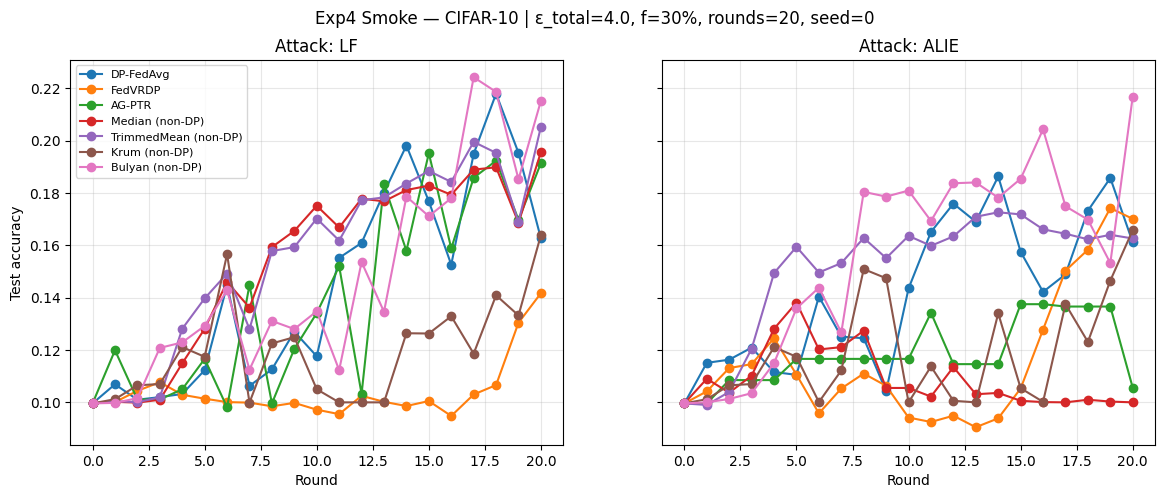

In [15]:
# Cell 14 — Experiment 4 SMOKE TEST (FAST)
# Dataset: CIFAR-10
# Attacks: {LF, ALIE}
# Fixed: f=30%, ε_total=4 (smoke)

seed = 0
eps_total = 4.0
delta = 1e-5
f = 0.20

ROUNDS = 20
LOCAL_EPOCHS = 1
BATCH_SIZE = 10

LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5

ATTACKS = ["LF", "ALIE"]
ALIE_Z = 2.0
ALIE_DIR = -1.0

# AG-PTR params
RHO = 0.79
TAU = 55
R_PUB_AVG = 8
PUB_BATCH = 20
PUB_SCALE = 0.1
PUBLIC_EPOCHS = 1

# DP baselines
CLIP_C_DP = 1.0
CLIP_C_VR = 0.5
K_FRAC = 0.3

# Robust non-DP baselines
INCLUDE_NONDP = True
ROBUST_AGGS = {
    "Median (non-DP)": "MEDIAN",
    "TrimmedMean (non-DP)": "TRIMMEAN",
    "Krum (non-DP)": "KRUM",
    "Bulyan (non-DP)": "BULYAN",
}

q = CLIENTS_PER_ROUND / len(clients)

# compute sigmas using FULL rounds target (like Exp3 did)
ROUNDS_FULL = 180
sigma_dp_full = find_sigma_for_target_eps_single(eps_total, q, ROUNDS_FULL, delta)

sel_factor = 2.0
sigma_rel_full = find_sigma_rel_for_target_eps_two(eps_total, q, ROUNDS_FULL, delta, sel_factor=sel_factor)
sigma_sel_full = sel_factor * sigma_rel_full

print(f"Exp4 Smoke: CIFAR-10 | ε_total={eps_total} | f={f} | attacks={ATTACKS}")
print("DP sigma (computed for 180 rounds):", sigma_dp_full)
print("AG sigmas sel/rel (computed for 180 rounds):", sigma_sel_full, sigma_rel_full)
print("NOTE: Robust baselines are NON-DP (no DP noise).")

METHODS = ["DP-FedAvg", "FedVRDP", "AG-PTR"] + (list(ROBUST_AGGS.keys()) if INCLUDE_NONDP else [])
curves = {atk: {} for atk in ATTACKS}
rows = []

for atk in ATTACKS:
    print("\n==============================")
    print("Smoke test attack:", atk)
    print("==============================")

    r_dp, c_dp = train_dp_fedavg_robust(
        seed, eps_total, f, sigma_dp_full, delta=delta,
        rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
        lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
        clip_C=CLIP_C_DP,
        attack=atk, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
        return_curve=True, record_every=1
    )

    r_vr, c_vr = train_fedvrdp_robust(
        seed, eps_total, f, sigma_dp_full, delta=delta,
        rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
        lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
        clip_C=CLIP_C_VR, k_frac=K_FRAC,
        attack=atk, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
        return_curve=True, record_every=1
    )

    r_ag, c_ag, ar_ag = train_ag_ptr(
        seed, eps_total, f,
        sigma_sel_full, sigma_rel_full, delta=delta,
        rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
        lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
        rho=RHO, tau=TAU,
        R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
        attack=atk, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
        allow_zero=False,
        return_curve=True, record_every=1
    )

    curves[atk]["DP-FedAvg"] = (r_dp, c_dp)
    curves[atk]["FedVRDP"]   = (r_vr, c_vr)
    curves[atk]["AG-PTR"]    = (r_ag, c_ag)

    row = {
        "attack": atk,
        "DP-FedAvg": float(c_dp[-1]),
        "FedVRDP": float(c_vr[-1]),
        "AG-PTR": float(c_ag[-1]),
        "AG-PTR_accept_rate": float(ar_ag),
    }

    if INCLUDE_NONDP:
        for name, agg in ROBUST_AGGS.items():
            r_rb, c_rb = train_robust_baseline(
                seed, f,
                agg=agg,
                rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
                lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
                attack=atk, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
                return_curve=True, record_every=1
            )
            curves[atk][name] = (r_rb, c_rb)
            row[name] = float(c_rb[-1])

    rows.append(row)

df_smoke = pd.DataFrame(rows)
display(df_smoke)

# Plot: 2 panels (one per attack)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, atk in enumerate(ATTACKS):
    ax = axes[i]
    for m in METHODS:
        r, c = curves[atk][m]
        ax.plot(r, c, marker="o", label=m)
    ax.set_title(f"Attack: {atk}")
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Test accuracy")
axes[0].legend(fontsize=8)
plt.suptitle(f"Exp4 Smoke — CIFAR-10 | ε_total={eps_total}, f=30%, rounds={ROUNDS}, seed={seed}")
plt.show()

FULL Exp3 settings:
  ε_total=2.0, δ=1e-05, f=0.2, rounds=180, record_every=5
  DP sigma (FedAvg/FedVRDP): 0.9723217465539842
  AG-PTR sigmas sel/rel: 1.965902445173369 0.9829512225866845
  Attacks: ['LF', 'ALIE', 'FANG']
  DP-FANG gamma: 2.0
  Include non-DP robust baselines: True

FULL run attack: LF


BULYAN (non-DP) atk=LF f=20%: 100%|██████████| 180/180 [03:47<00:00,  1.26s/it]


FULL run attack: ALIE



BULYAN (non-DP) atk=ALIE f=20%: 100%|██████████| 180/180 [02:56<00:00,  1.02it/s]


FULL run attack: FANG



BULYAN (non-DP) atk=FANG f=20%: 100%|██████████| 180/180 [02:54<00:00,  1.03it/s]


,attack,DP-FedAvg_mean,DP-FedAvg_std,FedVRDP_mean,FedVRDP_std,AG-PTR_mean,AG-PTR_std,Median (non-DP)_mean,Median (non-DP)_std,TrimmedMean (non-DP)_mean,TrimmedMean (non-DP)_std,Krum (non-DP)_mean,Krum (non-DP)_std,Bulyan (non-DP)_mean,Bulyan (non-DP)_std,AG-PTR_accept_rate_mean,AG-PTR_accept_rate_std
0,LF,0.712967,0.013423,0.792800,0.006492,0.753500,0.008983,0.803400,0.004255,0.825333,0.001974,0.723100,0.014603,0.810100,0.004526,0.646296,0.065158
1,ALIE,0.648700,0.044048,0.706333,0.017174,0.759967,0.002444,0.736367,0.011881,0.607900,0.009753,0.716233,0.008247,0.812600,0.003888,0.512963,0.034645
2,FANG,0.759267,0.002517,0.784267,0.007705,0.767133,0.002007,0.695267,0.019555,0.573767,0.027688,0.728067,0.009602,0.598633,0.078625,0.366667,0.020787


Saved exp3_full_summary.csv
Saved exp3_full_curves_long.csv


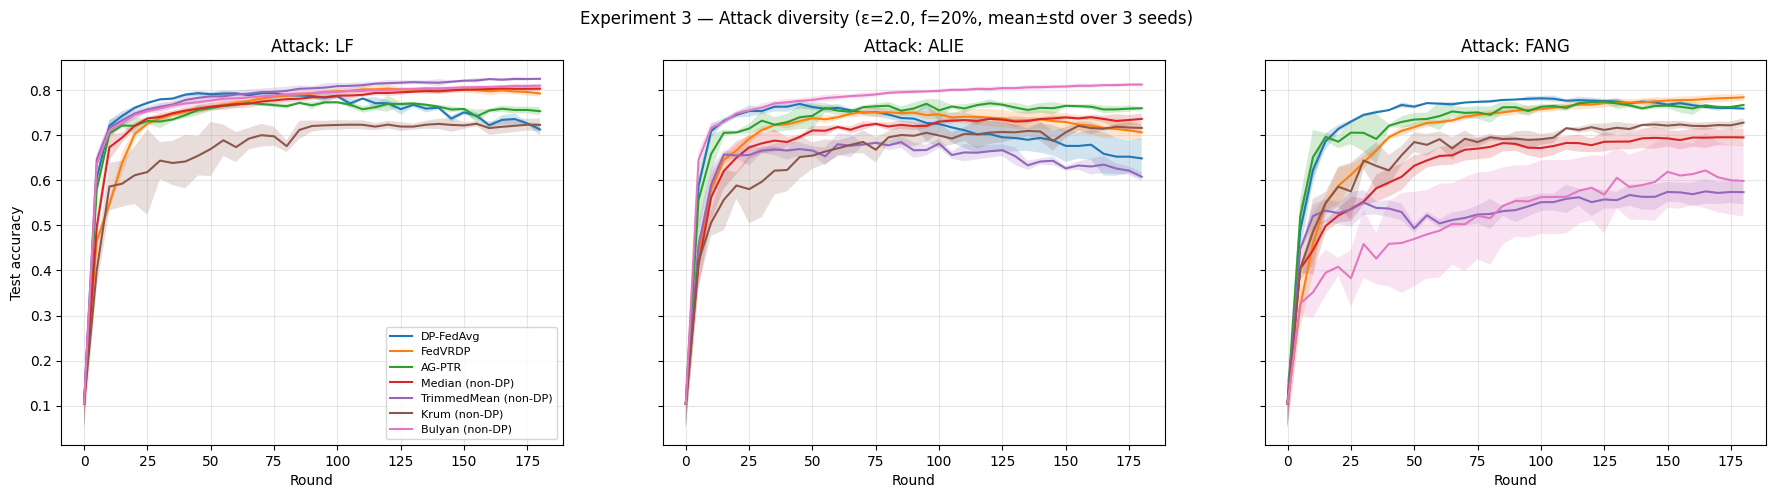

In [ ]:
# Cell 15 — FULL Experiment 4 (CIFAR-10)
# f = 30%
# ε_total ∈ {4, 8}
# Attacks: {LF, ALIE}
# Plots: accuracy vs rounds; optional accuracy vs ε_total (two points)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed_list = [0, 1, 2]

EPS_LIST = [4.0, 8.0]
delta = 1e-5
f = 0.20

ROUNDS = 180
LOCAL_EPOCHS = 10
BATCH_SIZE = 10

LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5

ATTACKS = ["LF", "ALIE"]

ALIE_Z = 2.0
ALIE_DIR = -1.0

# AG-PTR params (same as Exp3; tune TAU if accept_rate becomes too low)
RHO = 0.79
TAU = 55
R_PUB_AVG = 8
PUB_BATCH = 20
PUB_SCALE = 0.1
PUBLIC_EPOCHS = 1

# DP baselines params
CLIP_C_DP = 1.0
CLIP_C_VR = 0.5
K_FRAC = 0.30

# Non-DP robust baselines
INCLUDE_NONDP = True
ROBUST_AGGS = {
    "Median (non-DP)": "MEDIAN",
    "TrimmedMean (non-DP)": "TRIMMEAN",
    "Krum (non-DP)": "KRUM",
    "Bulyan (non-DP)": "BULYAN",
}
# Paper Fang params exist in code but NOT USED here since attacks are LF/ALIE.

RECORD_EVERY = 5
assert ROUNDS % RECORD_EVERY == 0, "RECORD_EVERY must divide ROUNDS."

DP_METHODS = ["DP-FedAvg", "FedVRDP", "AG-PTR"]
NONDP_METHODS = list(ROBUST_AGGS.keys()) if INCLUDE_NONDP else []
METHODS = DP_METHODS + NONDP_METHODS

round_axis = np.arange(0, ROUNDS + 1, RECORD_EVERY, dtype=int)

# ---- Privacy sampling rate ----
q = CLIENTS_PER_ROUND / len(clients)

# ---- Compute NON-DP curves once (they don't depend on epsilon) ----
curves_raw_nondp = {atk: {m: [] for m in NONDP_METHODS} for atk in ATTACKS}
if INCLUDE_NONDP:
    print("Computing NON-DP baselines once (reused for ε=4 and ε=8)...")
    for atk in ATTACKS:
        print("\n------------------------------")
        print("Non-DP baselines, attack:", atk)
        print("------------------------------")
        for seed in seed_list:
            for name, agg in ROBUST_AGGS.items():
                r_rb, c_rb = train_robust_baseline(
                    seed, f,
                    rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
                    lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
                    agg=agg, attack=atk,
                    alie_direction=ALIE_DIR, alie_z=ALIE_Z,
                    return_curve=True, record_every=RECORD_EVERY
                )
                curves_raw_nondp[atk][name].append(np.array(c_rb, dtype=float))

# ---- DP curves depend on epsilon ----
curves_raw_dp = {
    eps: {atk: {m: [] for m in DP_METHODS} for atk in ATTACKS}
    for eps in EPS_LIST
}
agptr_accept_rates = {eps: {atk: [] for atk in ATTACKS} for eps in EPS_LIST}

sigmas = {}

for eps_total in EPS_LIST:
    sigma_dp = find_sigma_for_target_eps_single(eps_total, q, ROUNDS, delta)

    sel_factor = 2.0
    sigma_rel = find_sigma_rel_for_target_eps_two(eps_total, q, ROUNDS, delta, sel_factor=sel_factor)
    sigma_sel = sel_factor * sigma_rel

    sigmas[eps_total] = {"sigma_dp": sigma_dp, "sigma_sel": sigma_sel, "sigma_rel": sigma_rel}

    print("\n==============================")
    print(f"FULL Exp4 ε_total={eps_total}")
    print("==============================")
    print("  DP sigma (FedAvg/FedVRDP):", sigma_dp)
    print("  AG-PTR sigmas sel/rel:", sigma_sel, sigma_rel)
    print("  f =", f, "| attacks =", ATTACKS, "| rounds =", ROUNDS, "| record_every =", RECORD_EVERY)

    for atk in ATTACKS:
        print("\n------------------------------")
        print(f"DP runs: attack={atk}, ε_total={eps_total}")
        print("------------------------------")

        for seed in seed_list:
            # DP-FedAvg
            r_dp, c_dp = train_dp_fedavg_robust(
                seed, eps_total, f, sigma_dp, delta=delta,
                rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
                lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
                clip_C=CLIP_C_DP,
                attack=atk, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
                return_curve=True, record_every=RECORD_EVERY
            )
            curves_raw_dp[eps_total][atk]["DP-FedAvg"].append(np.array(c_dp, dtype=float))

            # FedVRDP
            r_vr, c_vr = train_fedvrdp_robust(
                seed, eps_total, f, sigma_dp, delta=delta,
                rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
                lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
                clip_C=CLIP_C_VR, k_frac=K_FRAC,
                attack=atk, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
                return_curve=True, record_every=RECORD_EVERY
            )
            curves_raw_dp[eps_total][atk]["FedVRDP"].append(np.array(c_vr, dtype=float))

            # AG-PTR
            r_ag, c_ag, ar = train_ag_ptr(
                seed, eps_total, f,
                sigma_sel, sigma_rel, delta=delta,
                rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
                lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
                rho=RHO, tau=TAU,
                R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
                attack=atk, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
                allow_zero=False,
                return_curve=True, record_every=RECORD_EVERY
            )
            curves_raw_dp[eps_total][atk]["AG-PTR"].append(np.array(c_ag, dtype=float))
            agptr_accept_rates[eps_total][atk].append(float(ar))

# ---- Summarize mean±std ----
results = {eps: {atk: {} for atk in ATTACKS} for eps in EPS_LIST}

for eps_total in EPS_LIST:
    for atk in ATTACKS:
        # DP methods
        for m in DP_METHODS:
            mat = np.stack(curves_raw_dp[eps_total][atk][m], axis=0)
            results[eps_total][atk][m] = {"mean": mat.mean(axis=0), "std": mat.std(axis=0)}

        # non-DP methods (reused across eps)
        if INCLUDE_NONDP:
            for m in NONDP_METHODS:
                mat = np.stack(curves_raw_nondp[atk][m], axis=0)
                results[eps_total][atk][m] = {"mean": mat.mean(axis=0), "std": mat.std(axis=0)}

# ---- Summary table (final round) ----
summary_rows = []
for eps_total in EPS_LIST:
    for atk in ATTACKS:
        row = {"eps_total": eps_total, "attack": atk}
        for m in METHODS:
            row[f"{m}_mean"] = float(results[eps_total][atk][m]["mean"][-1])
            row[f"{m}_std"]  = float(results[eps_total][atk][m]["std"][-1])

        ar = np.array(agptr_accept_rates[eps_total][atk], dtype=float)
        row["AG-PTR_accept_rate_mean"] = float(ar.mean())
        row["AG-PTR_accept_rate_std"]  = float(ar.std())
        summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

df_summary.to_csv("exp4_full_summary.csv", index=False)
print("Saved exp4_full_summary.csv")

# ---- Save curves (long format) ----
records = []
for eps_total in EPS_LIST:
    for atk in ATTACKS:
        # DP methods have per-eps curves
        for m in DP_METHODS:
            for si, seed in enumerate(seed_list):
                curve = curves_raw_dp[eps_total][atk][m][si]
                for rr, acc in zip(round_axis, curve):
                    records.append({
                        "eps_total": eps_total, "attack": atk, "method": m,
                        "seed": seed, "round": int(rr), "acc": float(acc)
                    })

        # non-DP methods reused (replicated for each eps_total for convenience)
        if INCLUDE_NONDP:
            for m in NONDP_METHODS:
                for si, seed in enumerate(seed_list):
                    curve = curves_raw_nondp[atk][m][si]
                    for rr, acc in zip(round_axis, curve):
                        records.append({
                            "eps_total": eps_total, "attack": atk, "method": m,
                            "seed": seed, "round": int(rr), "acc": float(acc)
                        })

df_curves = pd.DataFrame(records)
df_curves.to_csv("exp4_full_curves_long.csv", index=False)
print("Saved exp4_full_curves_long.csv")

# ---- Plot: accuracy vs rounds (2x2 grid: rows=epsilon, cols=attack) ----
fig, axes = plt.subplots(len(EPS_LIST), len(ATTACKS), figsize=(22, 9), sharey=True, sharex=True)

for i, eps_total in enumerate(EPS_LIST):
    for j, atk in enumerate(ATTACKS):
        ax = axes[i, j] if len(EPS_LIST) > 1 else axes[j]
        for m in METHODS:
            mean = results[eps_total][atk][m]["mean"]
            std  = results[eps_total][atk][m]["std"]
            ax.plot(round_axis, mean, label=m)
            ax.fill_between(round_axis, mean - std, mean + std, alpha=0.2)

        ax.set_title(f"ε_total={eps_total} | attack={atk}")
        ax.set_xlabel("Round")
        ax.grid(True, alpha=0.3)

axes[0, 0].set_ylabel("Test accuracy")
axes[1, 0].set_ylabel("Test accuracy")
axes[0, 0].legend(fontsize=8)

plt.suptitle(f"Experiment 4 — CIFAR-10 | f=30% | mean±std over {len(seed_list)} seeds")
plt.show()

# ---- OPTIONAL: accuracy vs epsilon_total (two points) ----
PLOT_VS_EPS = True
if PLOT_VS_EPS:
    for atk in ATTACKS:
        plt.figure(figsize=(10, 5))
        for m in METHODS:
            ys = [float(results[eps][atk][m]["mean"][-1]) for eps in EPS_LIST]
            yerr = [float(results[eps][atk][m]["std"][-1]) for eps in EPS_LIST]
            plt.errorbar(EPS_LIST, ys, yerr=yerr, marker="o", capsize=4, label=m)
        plt.title(f"Exp4 — Final accuracy vs ε_total (attack={atk})")
        plt.xlabel("ε_total")
        plt.ylabel("Final test accuracy")
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=8)
        plt.show()